Epoch 1/100
40/40 - 3s - 66ms/step - loss: 0.2082 - val_loss: 0.1547
Epoch 2/100
40/40 - 1s - 25ms/step - loss: 0.1766 - val_loss: 0.1467
Epoch 3/100
40/40 - 1s - 24ms/step - loss: 0.1642 - val_loss: 0.1433
Epoch 4/100
40/40 - 1s - 24ms/step - loss: 0.1581 - val_loss: 0.1410
Epoch 5/100
40/40 - 1s - 24ms/step - loss: 0.1544 - val_loss: 0.1393
Epoch 6/100
40/40 - 1s - 24ms/step - loss: 0.1518 - val_loss: 0.1378
Epoch 7/100
40/40 - 1s - 24ms/step - loss: 0.1499 - val_loss: 0.1365
Epoch 8/100
40/40 - 1s - 24ms/step - loss: 0.1484 - val_loss: 0.1354
Epoch 9/100
40/40 - 1s - 24ms/step - loss: 0.1471 - val_loss: 0.1345
Epoch 10/100
40/40 - 1s - 24ms/step - loss: 0.1461 - val_loss: 0.1337
Epoch 11/100
40/40 - 1s - 24ms/step - loss: 0.1451 - val_loss: 0.1331
Epoch 12/100
40/40 - 1s - 24ms/step - loss: 0.1443 - val_loss: 0.1325
Epoch 13/100
40/40 - 1s - 24ms/step - loss: 0.1436 - val_loss: 0.1321
Epoch 14/100
40/40 - 1s - 25ms/step - loss: 0.1430 - val_loss: 0.1317
Epoch 15/100
40/40 - 1s - 28m

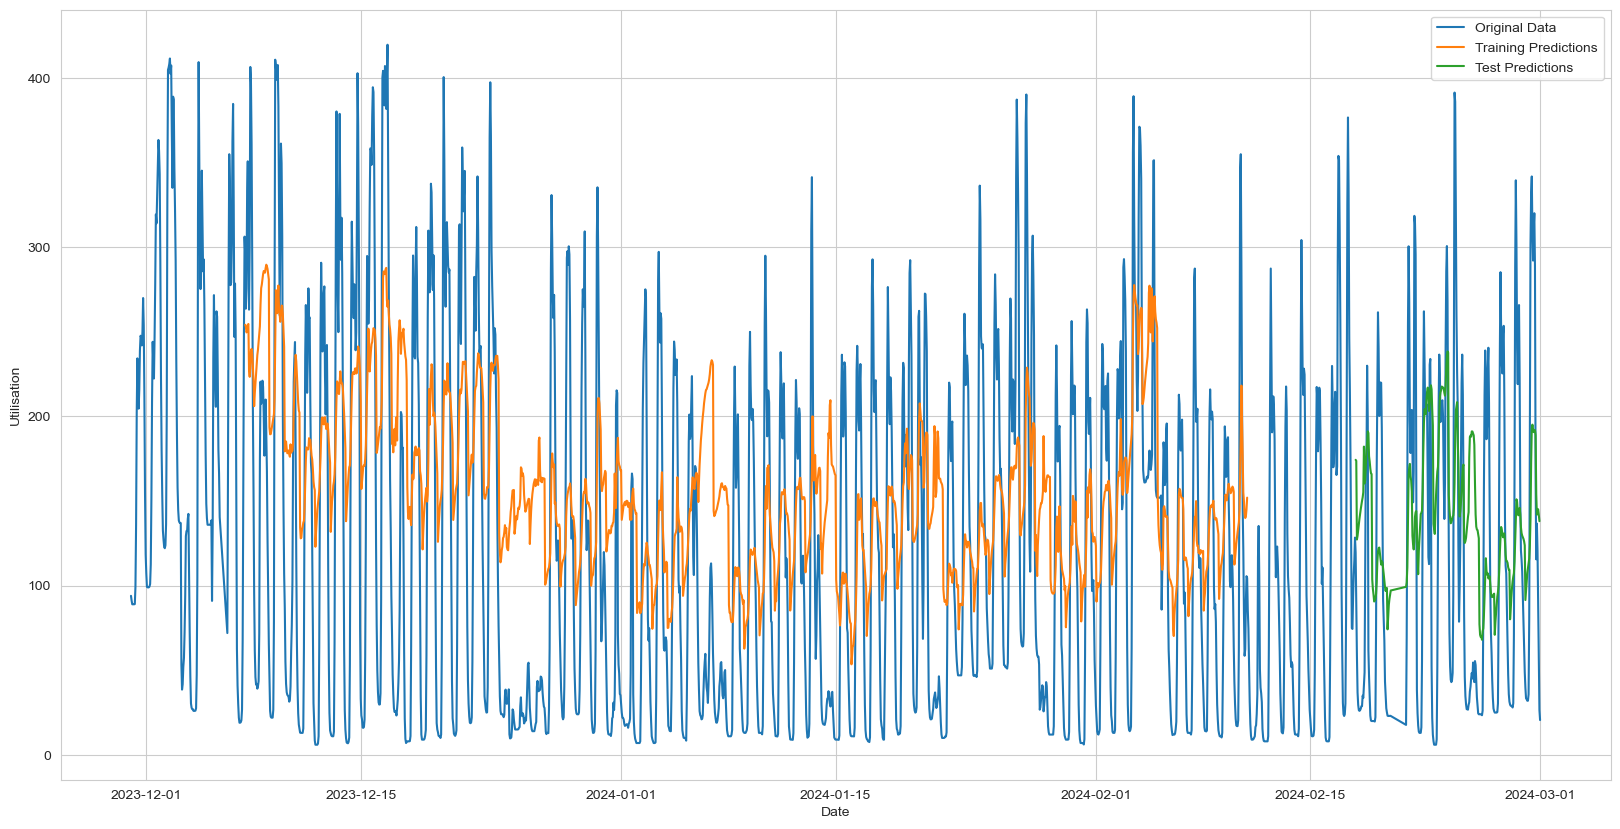

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers import Adam
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# convert an array of values into a dataset matrix
def create_dataset(dataset, window=168):
	dataX = []
	dataY = []
	for i in range(len(dataset)-window-1):
		dataX.append(dataset[i:(i+window), :])
		dataY.append(dataset[i + window, :])
	return np.array(dataX), np.array(dataY)

tf.random.set_seed(7)
data = pd.read_csv('./data/out_hourly.csv')
dataset = pd.DataFrame(data)
dataset = dataset.sort_values('timestamp')
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'])
start_date = pd.to_datetime('2023-11-30')
end_date = pd.to_datetime('2024-03-01')
dataset = dataset[(dataset['timestamp'] >= start_date) & (dataset['timestamp'] <= end_date)]
dataset['hour'] = dataset['timestamp'].dt.hour
dataset['dayOfWeek'] = dataset['timestamp'].dt.dayofweek
dataset['event_name'] = dataset['event_name'].apply(lambda x: 1 if isinstance(x, str) and x != "0" else 0)
dataset['holiday'] = dataset['holiday'].apply(lambda x: 1 if pd.notna(x) and isinstance(x, str) and x.strip() != "" else 0)

dataset.set_index('timestamp', inplace=True)
dates = dataset.index
columns_needed = ['value', 'rhum', 'tsun', 'event_name', 'holiday', 'hour', 'dayOfWeek']
dataset = dataset[[col for col in columns_needed if col in dataset.columns]]
#dataset = np.array(dataset)
dataset['value'] = dataset['value'].astype('float32').values.reshape(-1, 1)

start_dataset = dataset.copy()

scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

#dataset = pd.DataFrame(dataset, columns=dataset.columns)

#dataset[ np.isnan(dataset[:, 1]), 1 ] = 0

# split into train and test sets
train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train_df, test_df = dataset[0:train_size], dataset[train_size:len(dataset)]
train = train_df
test = test_df

# reshape into X=t and Y=t+1
window = 168
trainX, trainY = create_dataset(train, window)
testX, testY = create_dataset(test, window)
trainX = np.nan_to_num(trainX, nan=0.0)
testX = np.nan_to_num(testX, nan=0.0)
trainY = np.nan_to_num(trainY, nan=0.0)

testY = np.nan_to_num(testY, nan=0.0)


prediction_data = testX.copy()

# create and fit the LSTM network
model = Sequential()
#model.add(LSTM(168, return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])))
#model.add(Dropout(0.2))
#model.add(Dense(8, activation = 'relu'))
model.add(LSTM(1))
#model.add(Dropout(0.2))
model.add(Dense(1, activation = 'linear'))
model.compile(loss='mean_squared_error', optimizer=Adam(clipvalue=1.0))
model.fit(trainX, trainY, epochs=100, batch_size=32, verbose=2, validation_split=0.2)


# make predictions
trainPredict = model.predict(trainX)
trainPredict = np.clip(trainPredict, 0, 429)
print(trainPredict.shape)
testPredict = model.predict(testX)
testPredict = np.clip(testPredict, 0, 429)

# invert predictions
#invert the predictions before calculating error scores to ensure that performance is reported in the same units as the original data

trainPredict = scaler.inverse_transform(np.concatenate((trainPredict.reshape(-1,1), np.ones((len(trainPredict.reshape(-1,1)), 6))), axis=1))[:,0]
trainY = scaler.inverse_transform(trainY)
testPredict = scaler.inverse_transform(np.concatenate((testPredict.reshape(-1,1), np.ones((len(testPredict.reshape(-1,1)), 6))), axis=1))[:,0]
testY =scaler.inverse_transform(testY)



# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[:, 0], trainPredict))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[:, 0], testPredict))
print('Test Score: %.2f RMSE' % (testScore))
#rmse = np.sqrt(np.mean((trainY - trainPredict)**2))
#print(f'RMSE train: {rmse:.2f}')
#rmse = np.sqrt(np.mean((testY - testPredict)**2))
#print(f'RMSE test: {rmse:.2f}')

#shift the predictions so that they align on the x-axis with the original dataset. Once prepared, the data is plotted, showing the original dataset in blue, the predictions for the training dataset in green, and the predictions on the unseen test dataset in red
# shift train predictions for plotting
#Nach der Vorhersage musst du zurück-transformieren:

trainPredictPlot = np.empty_like(dataset[:, 0])
trainPredictPlot[:] = np.nan
trainPredictPlot[window:len(trainPredict)+window] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset[:, 0])
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict)+(window*2)+1:len(dataset)-1] = testPredict
"""
# Initialisiere Plots als NaN-Arrays gleicher Länge wie dataset
trainPredictPlot = np.empty_like(dataset[:, 0])  # Nur erste Spalte (value), shape (n,)
trainPredictPlot[:] = np.nan
trainPredictPlot[window:window+len(trainPredict)] = trainPredict
testPredictPlot = np.empty_like(dataset[:, 0])   # Nur erste Spalte (value), shape (n,)
testPredictPlot[:] = np.nan

# Setze die Vorhersagen an die richtige Stelle im Zeitverlauf
testPredictPlot[window+len(trainPredict)+1:window+len(trainPredict)+1+len(testPredict)] = testPredict
"""



# plot baseline and predictions
plt.figure(figsize=(20, 10))
dataset = scaler.inverse_transform(dataset)
plt.plot(dates, dataset[:, 0] , label='Original Data')
plt.plot(dates, trainPredictPlot, label='Training Predictions')
plt.plot(dates, testPredictPlot, label='Test Predictions')
plt.xlabel('Date')
plt.ylabel('Utilisation')
plt.legend()
plt.show()
